In [ ]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import torch

torch.set_num_threads(1)
torch.multiprocessing.set_sharing_strategy("file_system")

import scvi

scvi.settings.num_threads = 1
scvi.settings.dl_num_workers = 8
scvi.settings.dl_persistent_workers = False

In [ ]:
import sys
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import scanpy as sc
import scanpy.external as sce
import anndata as ad
from anndata import AnnData

from scipy import sparse
from tqdm import tqdm

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 500)

# Skin

### explore reference from https://www.science.org/doi/10.1126/science.aba6500

In [ ]:
ct_ref = sc.read_h5ad("h_skin/Fskin_obj_2_1_2_3_webatlas.h5ad")

In [6]:
ct_ref.obs.origin.value_counts()

origin
fetal       432169
adult       197812
organoid    114278
Name: count, dtype: int64

In [ ]:
ct_ref = ct_ref[ct_ref.obs.origin == "adult"]

In [ ]:
columns_fyi = [
    "donor",
    "predicted_doublets",
    "chemistry",
    "gender",
    # 'sorting', 'sample', 'annotation_broad', # empty series
    "annotation_verybroad_adult",
    "annotation_broad_adult",
    "annotation_fine_adult_v2",
    "annotation_fine_adult",
]

for key in columns_fyi:
    display(ct_ref.obs[key].value_counts())
    display("-----------------------")

donor
S4    50781
S1    50436
S5    50198
S2    28381
S3    18016
Name: count, dtype: int64

'-----------------------'

predicted_doublets
False    197812
Name: count, dtype: int64

'-----------------------'

chemistry
SC5P-R2    100979
SC3Pv2      96833
Name: count, dtype: int64

...

'-----------------------'

annotation_fine_adult_v2
Differentiated_KC      25738
Undifferentiated_KC    21372
Th                     21133
VE2                    16402
F1                     10333
VE1                     9393
Tc                      9170
Macro_1                 5754
Treg                    5676
LC_4                    5367
Mono_mac                4758
Pericyte_1              4745
moDC_2                  4638
moDC_1                  4489
F2                      4448
LC_2                    4350
Differentiated_KC2      4151
LE2                     3972
Melanocyte              3724
moDC_3                  3157
F3                      3052
ILC1_3                  2927
ILC1_NK                 2599
LC_3                    2495
MigDC                   1935
Proliferating_KC        1842
Plasma                  1487
Macro_2                 1317
Inf_mac                 1068
LE1                     1057
ILC2                     754
NK                       735
Mast_cell                715
DC2               

'-----------------------'

annotation_fine_adult
Th                                     21133
VE2                                    16402
c1                                     14264
c3                                     12683
F1                                     10333
VE1                                     9393
Tc                                      9170
c5                                      7108
c7                                      6961
Macro_1                                 5754
Treg                                    5676
LC_4                                    5367
Mono                                    4758
Pericyte_1_non_inflamm                  4745
moDC_2                                  4638
moDC_1                                  4489
F2                                      4448
LC_2                                    4350
c8                                      4151
LE2                                     3972
C_Melanocyte                            3724
c6                               

'-----------------------'

In [ ]:
ct_ref = ct_ref[ct_ref.obs.annotation_fine_adult_v2 != "doublet"]

In [ ]:
adata_skin = sc.read_h5ad("./h_skin/skin_QC_dbl_SenCIDenv.h5ad")
ref_skin = ct_ref.copy()

#### Prep data

In [ ]:
"""check ref object"""

print(
    "adata.X: min =",
    ref_skin.X.min(),
    ", max =",
    ref_skin.X.max(),
    ", mean ≈",
    ref_skin.X.mean(),
)
if ref_skin.raw:
    print(
        "adata.raw.X: min =",
        ref_skin.raw.X.min(),
        ", max =",
        ref_skin.raw.X.max(),
        ", mean ≈",
        ref_skin.raw.X.mean(),
    )

for key in ref_skin.layers:
    layer = ref_skin.layers[key]
    print(f"{key}: min = {layer.min()}, max = {layer.max()}, mean ≈ {layer.mean()}")
print("\n")

adata.X: min = 0.0 , max = 8.790998 , mean ≈ 0.062963456
adata.raw.X: min = 0.0 , max = 19057.0 , mean ≈ 0.20670235




In [15]:
ref_skin = ref_skin.raw.to_adata().copy()

In [ ]:
ref_skin.obs = ref_skin.obs.rename(columns={"donor": "GSM_id"})
ref_skin.obs = ref_skin.obs.rename(columns={"chemistry": "Methodics"})
ref_skin.obs["Methodics"] = ref_skin.obs["Methodics"].cat.rename_categories(
    {"SC3Pv2": "10X Genomics v2"}
)
ref_skin.obs["GSE_id"] = pd.Series(
    "unknown", index=ref_skin.obs.index, dtype="category"
)


In [17]:
adata_skin.obs["Methodics"] = (
    adata_skin.obs["Methodics"]
    .astype(str)
    .replace("10X Genomics v 3.1", "10X Genomics v3.1")
    .astype("category")
)


In [ ]:
adata_skin.obs["annotation_fine_adult_v2"] = pd.Series(
    "Unlabeled", index=adata_skin.obs.index, dtype="category"
)
adata_skin.obs["Batch"] = pd.Series(
    "query", index=adata_skin.obs.index, dtype="category"
)

In [ ]:
ref_skin.obs["Batch"] = pd.Series("ref", index=ref_skin.obs.index, dtype="category")

#### `celltypist` anno

In [25]:
import celltypist

In [ ]:
adata_celltypist = adata_skin.copy()  # make a copy of our adata
# adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts

sc.pp.normalize_per_cell(
    adata_celltypist, counts_per_cell_after=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform

# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [ ]:
h_skin_model = celltypist.models.Model.load(model="Adult_Human_Skin.pkl")

In [ ]:
%%time

ct_preds = celltypist.annotate(
    adata_celltypist, model=h_skin_model, majority_voting=True
)

ct_preds_adata = ct_preds.to_adata()

🔬 Input data has 181653 cells and 32568 genes
🔗 Matching reference genes in the model
🧬 3126 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 25
🗳️ Majority voting the predictions
✅ Majority voting done!


CPU times: user 3min 9s, sys: 3min 2s, total: 6min 12s
Wall time: 5min 15s


In [ ]:
adata_skin.obs["ct_anno"] = ct_preds_adata.obs.loc[
    adata_skin.obs.index, "majority_voting"
]
adata_skin.obs["ct_pred_wo_mv"] = ct_preds_adata.obs.loc[
    adata_skin.obs.index, "predicted_labels"
]
adata_skin.obs["ct_conf_score"] = ct_preds_adata.obs.loc[
    adata_skin.obs.index, "conf_score"
]

#### Gene ID mapping (no ENSG -> Gene ID)

In [30]:
adata_skin.layers["counts"] = adata_skin.X.copy()
adata_skin.raw = adata_skin

In [31]:
shared_genes = adata_skin.var_names.intersection(ref_skin.var_names)
adata_skin = adata_skin[:, shared_genes].copy()
ref_skin = ref_skin[:, shared_genes].copy()

In [ ]:
# тут поменяла: hvg на query -> фильтрация ref; 5k hvg instead of 3k
sc.pp.highly_variable_genes(
    adata_skin, flavor="seurat_v3", n_top_genes=3000, subset=True
)
ref_skin = ref_skin[:, adata_skin.var_names].copy()

### scVI

In [ ]:
scvi.model.SCVI.setup_anndata(
    ref_skin,
    batch_key="Batch",
    categorical_covariate_keys=["Methodics", "GSM_id", "GSE_id"],
)

In [ ]:
ref_skin_vae = scvi.model.SCVI(
    ref_skin,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)

In [ ]:
ref_skin_vae.train(max_epochs=60, early_stopping=True, early_stopping_patience=10)

In [ ]:
ref_skin_vae.save("./h_skin/sc/ref_skin_scVI", overwrite=True)

In [38]:
ref_skin.obsm["X_scVI"] = ref_skin_vae.get_latent_representation()
sc.pp.neighbors(ref_skin, use_rep="X_scVI")
sc.tl.leiden(ref_skin, flavor="igraph", n_iterations=2)
sc.tl.umap(ref_skin)

In [41]:
scvi.model.SCVI.prepare_query_anndata(adata_skin, ref_skin_vae)
adata_skin_vae = scvi.model.SCVI.load_query_data(adata_skin, ref_skin_vae)

INFO     Found 100.0% reference vars in query data.                                                                


In [ ]:
adata_skin_vae.train(
    max_epochs=100,
    early_stopping=True,
    early_stopping_patience=10,
    plan_kwargs={"weight_decay": 0.0},
)
adata_skin_vae.save("./h_skin/sc/adata_skin_scVI", overwrite=True)

In [46]:
adata_skin.obsm["X_scVI"] = adata_skin_vae.get_latent_representation()
sc.pp.neighbors(adata_skin, use_rep="X_scVI")
sc.tl.leiden(adata_skin, flavor="igraph", n_iterations=2)
sc.tl.umap(adata_skin)

### scANVI

In [ ]:
adata_skin = sc.read_h5ad("adata_skin_int_after_scVI.h5ad")
ref_skin = sc.read_h5ad("ref_skin_int_after_scVI.h5ad")

In [ ]:
adata_skin_vae = scvi.model.SCVI.load("./h_skin/sc/adata_skin_scVI", adata=adata_skin)
ref_skin_vae = scvi.model.SCVI.load("./h_skin/sc/ref_skin_scVI", adata=ref_skin)

INFO     File ./h_skin/sc/adata_skin_scVI/model.pt already downloaded                                              
INFO     File ./h_skin/sc/ref_skin_scVI/model.pt already downloaded                                                


In [ ]:
ref_skin_scanvi = scvi.model.SCANVI.from_scvi_model(
    ref_skin_vae, unlabeled_category="Unlabeled", labels_key="annotation_fine_adult_v2"
)

In [ ]:
ref_skin_scanvi.train(max_epochs=20, early_stopping=True, early_stopping_patience=5)
ref_skin_scanvi.save("./h_skin/sc/ref_skin_scANVI", overwrite=True)

In [ ]:
ref.obsm["X_scANVI"] = ref_scanvi.get_latent_representation()
sc.pp.neighbors(ref, use_rep="X_scANVI")
sc.tl.leiden(ref, flavor="igraph", n_iterations=2)
sc.tl.umap(ref)

In [ ]:
scvi.model.SCANVI.prepare_query_anndata(
    adata_skin, ref_skin_scanvi
)  # again a no-op, but good practice to use
adata_skin_scanvi = scvi.model.SCANVI.load_query_data(adata_skin, ref_skin_scanvi)

INFO     Found 100.0% reference vars in query data.                                                                


In [ ]:
adata_skin_scanvi.train(
    max_epochs=60,
    early_stopping=True,
    early_stopping_patience=3,
    plan_kwargs={"weight_decay": 0.0},
)  # max_epochs=100,
adata_skin_scanvi.save("./h_skin/sc/adata_skin_scANVI", overwrite=True)

In [ ]:
sc.pp.neighbors(adata_skin, use_rep="X_scANVI")
sc.tl.leiden(adata_skin, flavor="igraph", n_iterations=2)

sc.tl.umap(adata_skin)

In [ ]:
adata_skin.obs["scanvi_pred"] = adata_skin_scanvi.predict()
adata_skin.obs["scanvi_probabilities"] = adata_skin_scanvi.predict(
    adata_skin, soft=True
).max(axis=1)

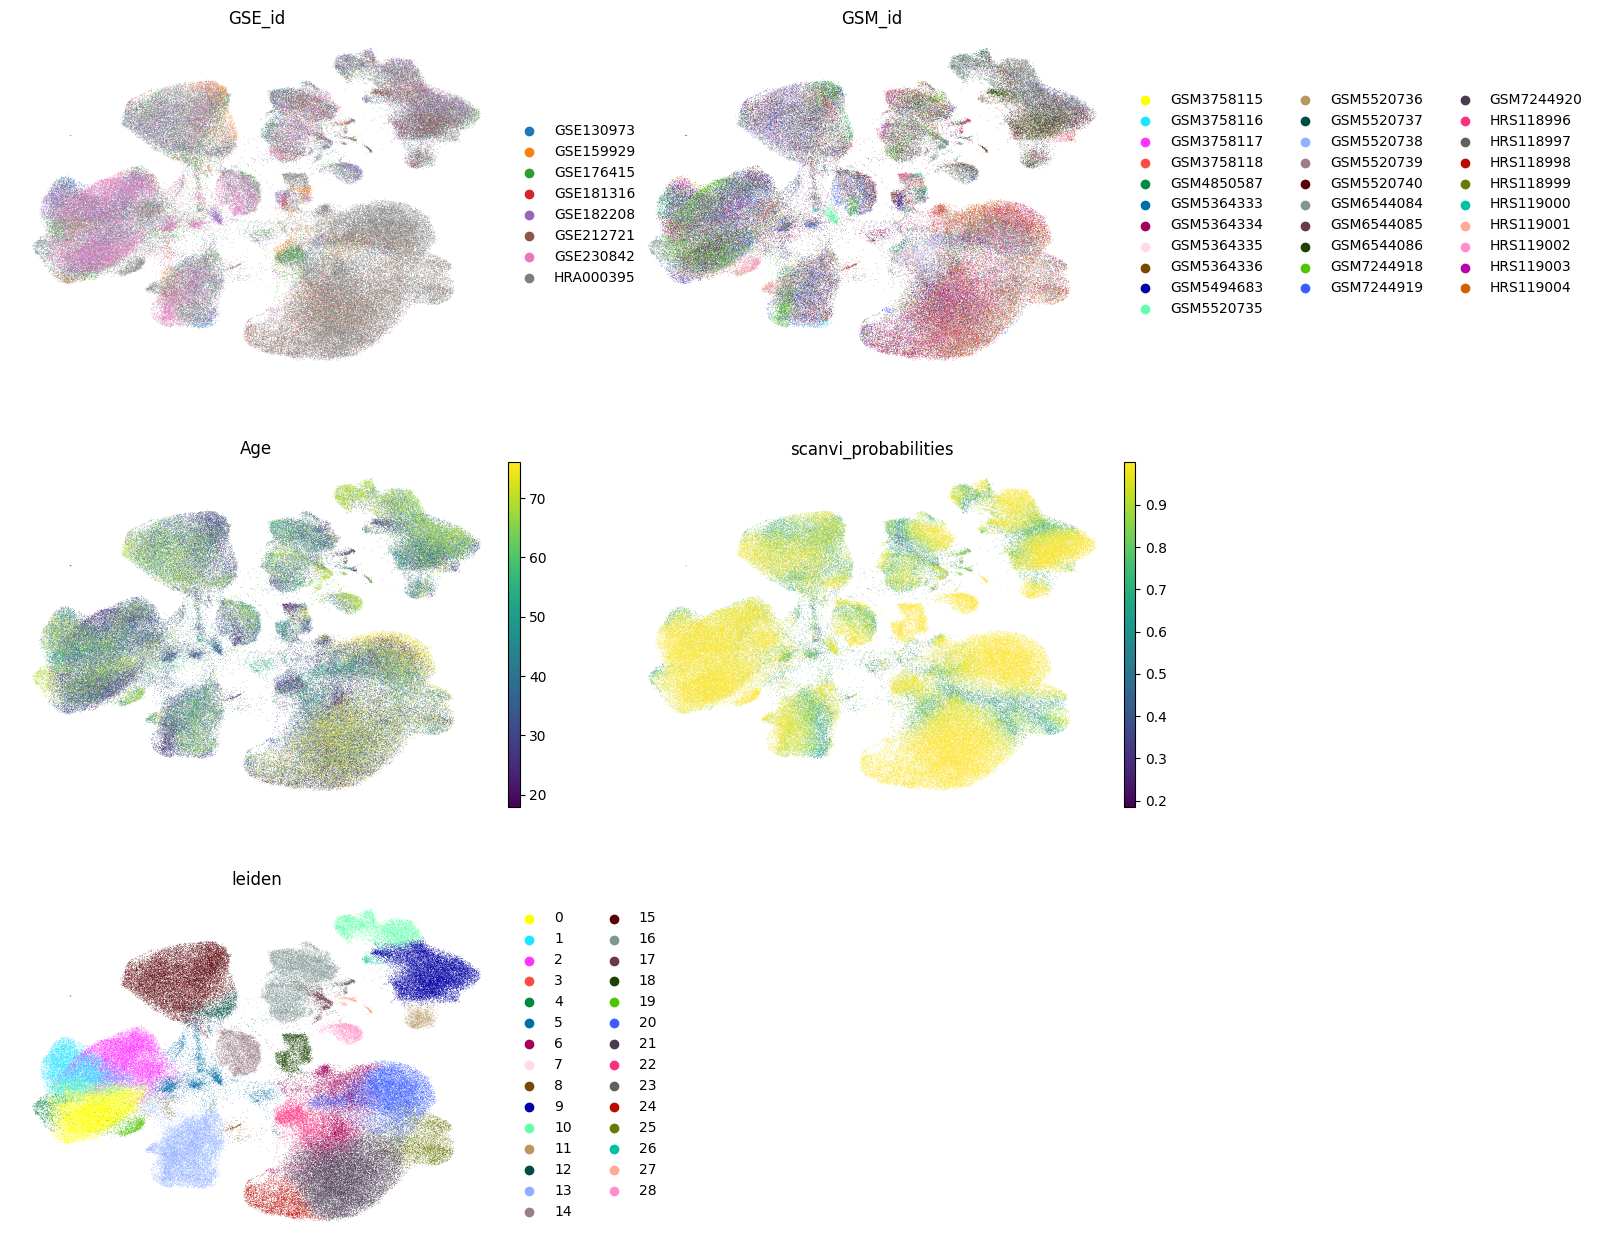

In [ ]:
sc.pl.umap(
    adata_skin,
    color=["GSE_id", "GSM_id", "Age", "scanvi_probabilities", "leiden"],
    frameon=False,
    ncols=2,
)

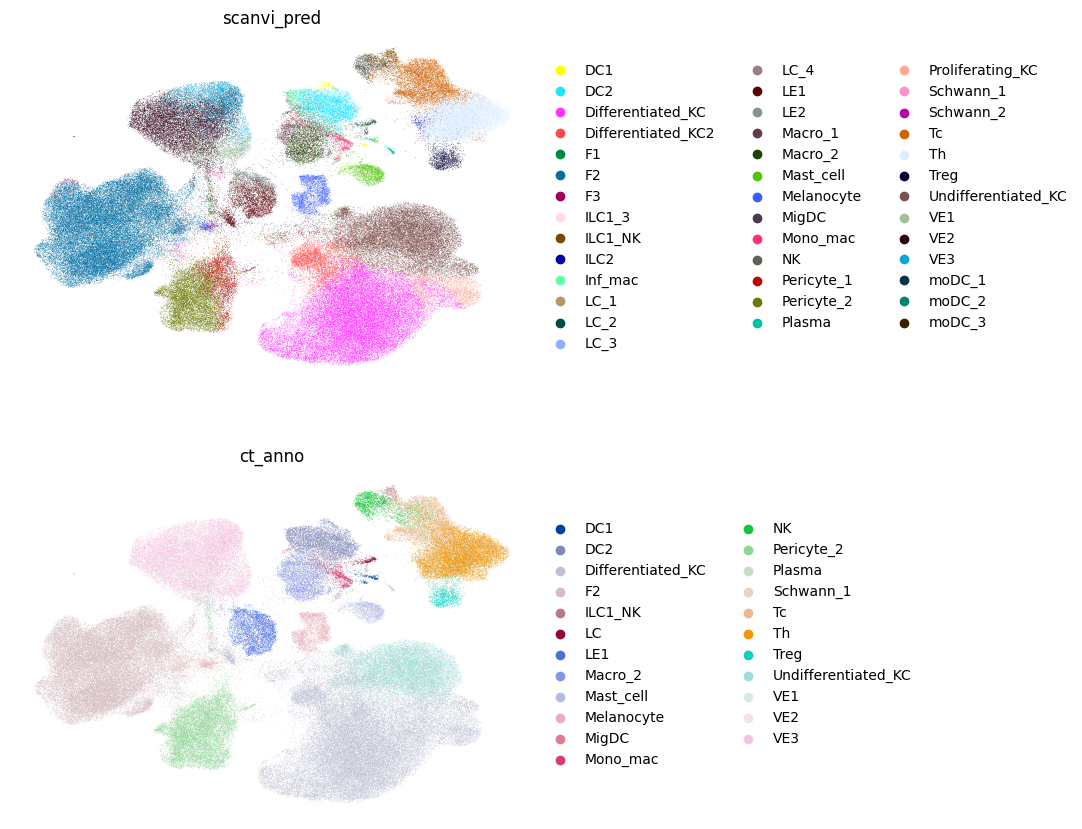

In [ ]:
sc.pl.umap(adata_skin, color=["scanvi_pred", "ct_anno"], frameon=False, ncols=1)

In [ ]:
adata_skin.write("./h_skin/sc/adata_skin_hvg_scVI_scANVI.h5ad")
ref_skin.write("./h_skin/sc/ref_skin_hvg_scVI_scANVI.h5ad")

### Refine anno

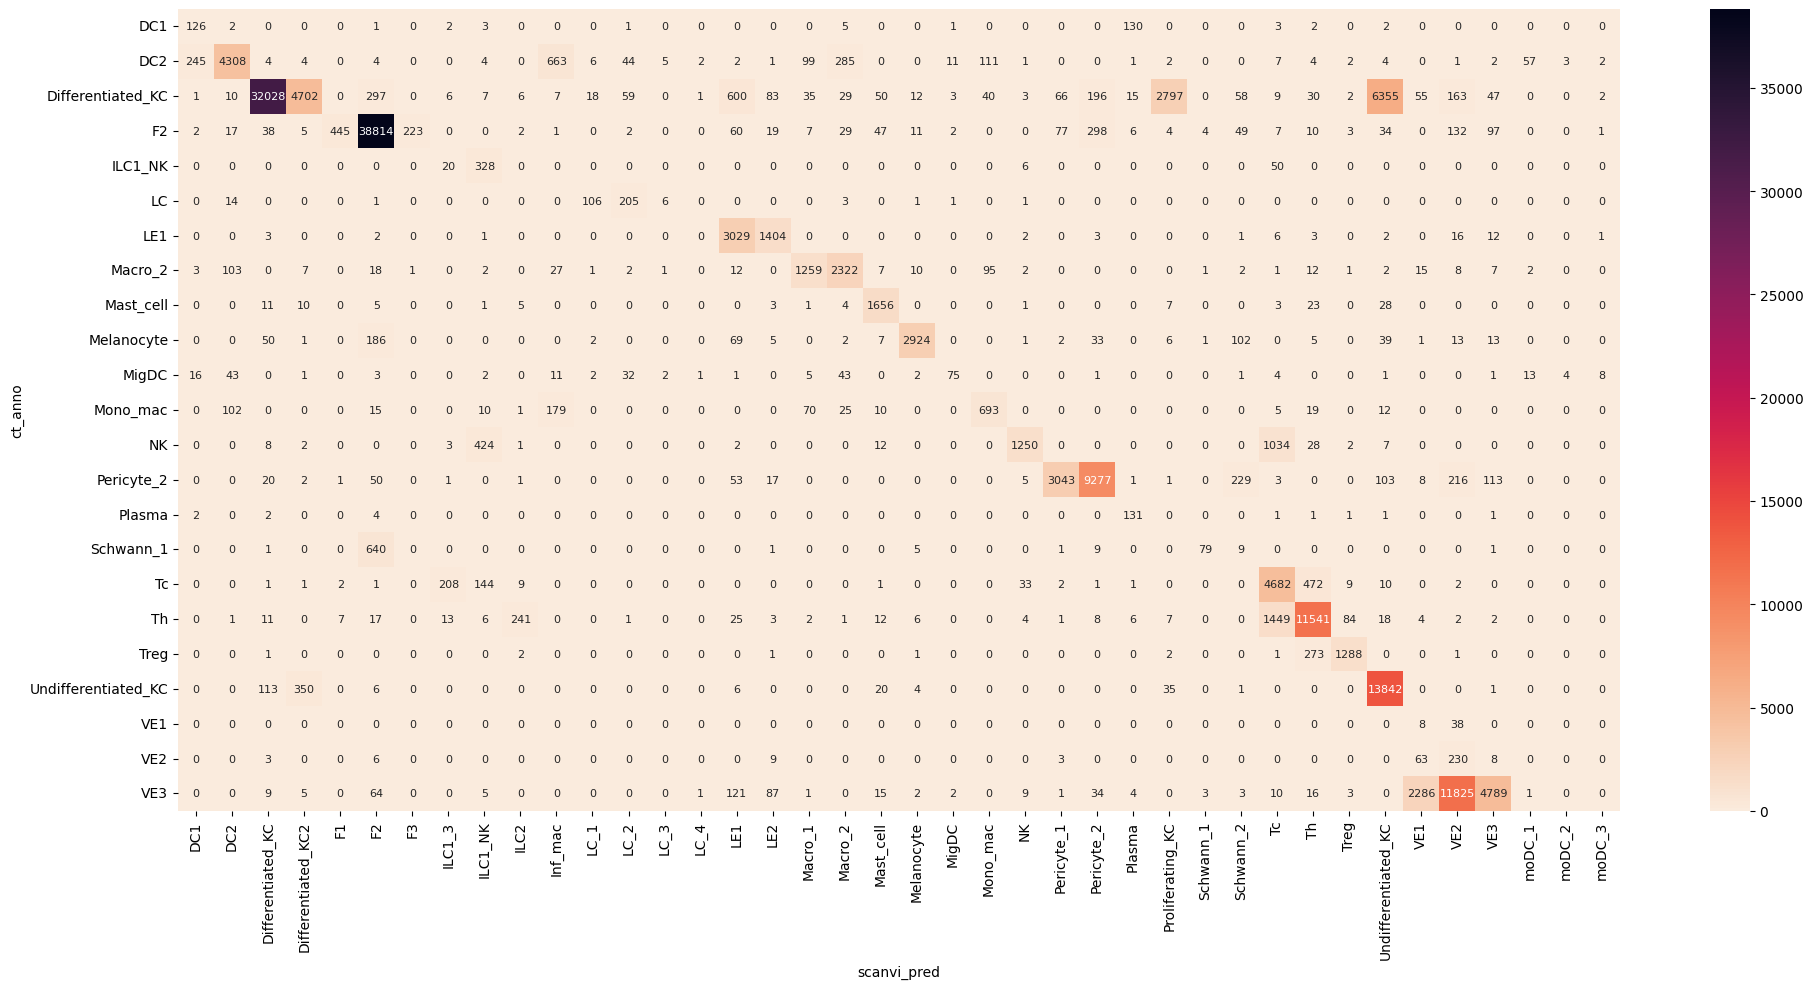

In [ ]:
# Перекрестная таблица частот - heatmap
ct = pd.crosstab(adata_skin.obs["ct_anno"], adata_skin.obs["scanvi_pred"])

plt.figure(figsize=(20, 10))
sns.heatmap(ct, annot=True, fmt="d", cmap="rocket_r", annot_kws={"size": 8})
# plt.xlabel()
# plt.ylabel()
# plt.title()
# plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

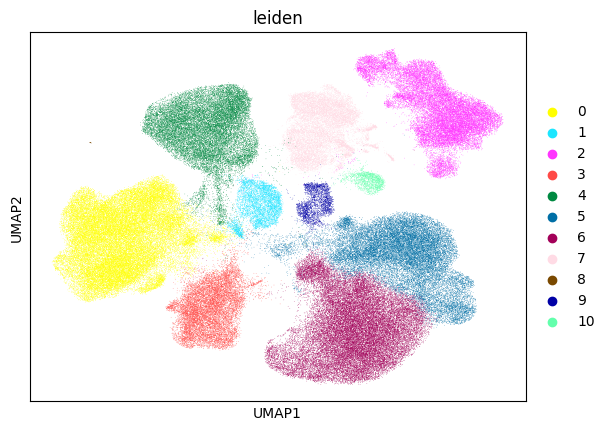

In [ ]:
sc.pl.umap(adata_skin, color=["leiden"], ncols=1)

In [ ]:
adt = adata_skin[adata_skin.obs.leiden == "2"]  # lymphocytes

In [ ]:
sc.pl.umap(
    adt,
    color=[
        "FOXP3",
        "IL2RA",
        "CTLA4",
        "IKZF2",
        "TIGIT",
        "CD4",
        "IL7R",
        "GATA3",
        "TBX21",
        "RORC",
        "CD8A",
        "GZMA",
        "GZMB",
        "GZMH",
        "KLRG1",
        "NCR1",
        "NCR3",
        "NCAM1",
        "EOMES",
        "PRF1",
        "TNFSF11",
        "LTB",
        "IL7R",
        "AHR",
        "ID2",
    ],
    ncols=5,
    sort_order=True,
)

In [ ]:
adata_skin.obs["cell_type_final"] = pd.NA
adt.obs["cell_type_final"] = pd.NA

In [ ]:
adt.obs.loc[adt.obs.leiden == "3", "cell_type_final"] = "NK"
adt.obs.loc[adt.obs.leiden == "0", "cell_type_final"] = "CD8T"
adt.obs.loc[adt.obs.leiden == "1", "cell_type_final"] = "CD4T"
adt.obs.loc[adt.obs.leiden == "2", "cell_type_final"] = "Treg"

In [ ]:
common_idx = adata_skin.obs.index.intersection(adt.obs.index)
adata_skin.obs.loc[common_idx, "cell_type_final"] = adt.obs.loc[
    common_idx, "cell_type_final"
]

In [ ]:
adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(["Pericyte_1", "Pericyte_2"]), "cell_type_final"
] = "Pericyte"
adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(["Schwann_1", "Schwann_2"]), "cell_type_final"
] = "Schwann cell"
adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(["LE1", "LE2"]), "cell_type_final"
] = "LE"
adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(
        ["DC1", "DC2", "MigDC", "moDC_1", "moDC_2", "moDC_3"]
    ),
    "cell_type_final",
] = "DC"
adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(["VE1", "VE2", "VE3"]), "cell_type_final"
] = "VE"
adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(["Macro_1", "Macro_2", "Inf_mac", "Mono_mac"]),
    "cell_type_final",
] = "Macrophage"

adata_skin.obs.loc[
    (adata_skin.obs["scanvi_pred"].isin(["Differentiated_KC", "Differentiated_KC2"]))
    & (adata_skin.obs["leiden"].isin(["5", "6"])),
    "cell_type_final",
] = "Differentiated_KC"
adata_skin.obs.loc[
    (adata_skin.obs["scanvi_pred"] == "Undifferentiated_KC")
    & (adata_skin.obs["leiden"].isin(["5", "6"])),
    "cell_type_final",
] = "Undifferentiated_KC"
adata_skin.obs.loc[
    (adata_skin.obs["scanvi_pred"] == "Proliferating_KC")
    & (adata_skin.obs["leiden"].isin(["5", "6"])),
    "cell_type_final",
] = "Proliferating_KC"

adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(["F1", "F2", "F3"]), "cell_type_final"
] = "Fibroblast"
adata_skin.obs.loc[adata_skin.obs["scanvi_pred"] == "Plasma", "cell_type_final"] = (
    "Plasma cell"
)
adata_skin.obs.loc[
    adata_skin.obs["scanvi_pred"].isin(["LC_1", "LC_2", "LC_3", "LC_4"]),
    "cell_type_final",
] = "LC"
adata_skin.obs.loc[adata_skin.obs["leiden"] == "9", "cell_type_final"] = "Melanocyte"
adata_skin.obs.loc[adata_skin.obs["leiden"] == "10", "cell_type_final"] = "Mast cell"

In [ ]:
adata_skin.obs["cell_type_final"] = adata_skin.obs["cell_type_final"].fillna(
    "Unlabeled"
)

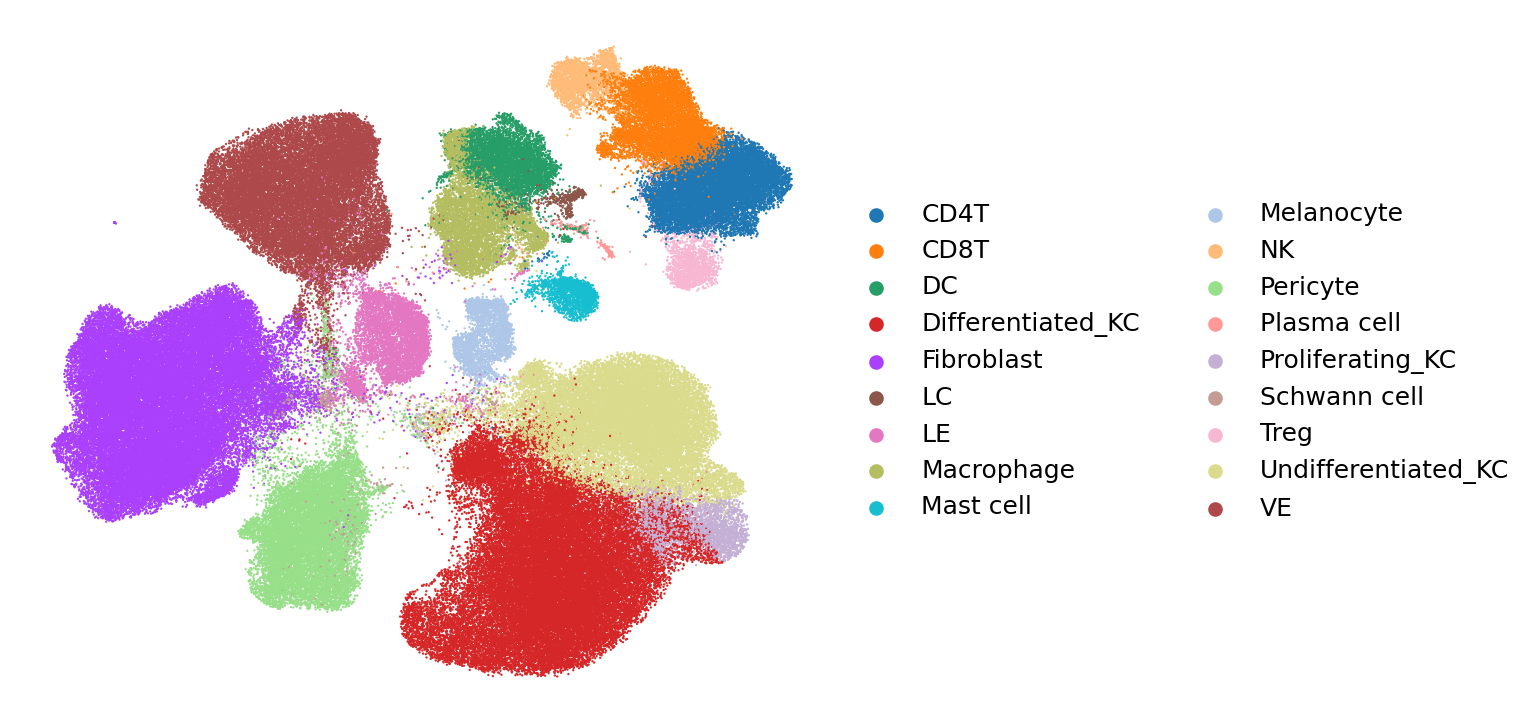

In [ ]:
with plt.rc_context({"figure.figsize": (7, 6), "figure.dpi": 150}):
    sc.pl.umap(
        adata_skin[adata_skin.obs.cell_type_final != "Unlabeled"],
        color=["cell_type_final"],
        title="",
        frameon=False,
        size=5,
        legend_fontsize=12,
    )

In [ ]:
adata_skin.write("./h_skin/sc/adata_skin_hvg_scVI_scANVI.h5ad")